# 01 — Data Understanding

## Objective

This notebook documents the structure and initial data-quality
characteristics of the Home Credit dataset.

The objectives are to:

- inventory the available data files;
- identify the unit of observation of each table;
- document table keys and relationships;
- verify the structure of the application data;
- examine the target distribution;
- quantify missing values and feature cardinality;
- identify potential anomalies requiring further investigation.

No preprocessing, feature engineering or machine-learning model is
implemented in this notebook.

In [1]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = Path("../data/raw")


## 1. Data file inventory

This section inventories the available CSV files and their disk sizes.

File size provides an initial indication of the memory and computation
requirements associated with each table.

In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

file_inventory = pd.DataFrame(
    {
        "file_name": [path.name for path in csv_files],
        "size_mb": [
            round(path.stat().st_size / (1024**2), 2)
            for path in csv_files
        ],
    }
)

file_inventory

,file_name,size_mb
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
5,HomeCredit_columns_description.csv,0.04
6,installments_payments.csv,689.62
7,POS_CASH_balance.csv,374.51
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


## 2. Dataset tables and units of observation

| Table | Unit of observation | Main linking keys |
|---|---|---|
| `application_train` | One current loan application with an observed target | `SK_ID_CURR` |
| `application_test` | One current loan application without an observed target | `SK_ID_CURR` |
| `bureau` | One previous credit reported by the Credit Bureau | `SK_ID_CURR`, `SK_ID_BUREAU` |
| `bureau_balance` | One monthly status record for a Bureau credit | `SK_ID_BUREAU`, `MONTHS_BALANCE` |
| `previous_application` | One previous Home Credit application | `SK_ID_CURR`, `SK_ID_PREV` |
| `POS_CASH_balance` | One monthly balance record for a previous POS or cash loan | `SK_ID_CURR`, `SK_ID_PREV`, `MONTHS_BALANCE` |
| `credit_card_balance` | One monthly credit-card balance record | `SK_ID_CURR`, `SK_ID_PREV`, `MONTHS_BALANCE` |
| `installments_payments` | One recorded installment payment | `SK_ID_CURR`, `SK_ID_PREV` |

The listed columns are linking keys or candidate keys. Their presence
does not automatically imply that they form a unique primary key.

## 3. Relational structure

    application_train / application_test
                      |
                      | SK_ID_CURR
                      |
           +----------+--------------------------+
           |                     |               |
         bureau        previous_application   installments_payments
           |                     |
           | SK_ID_BUREAU        | SK_ID_PREV
           |                     |
    bureau_balance      +---------+------------------+
                        |                            |
               POS_CASH_balance          credit_card_balance

The application tables contain one row per current application.

The historical tables contain multiple observations for the same
applicant. Therefore, these tables cannot be joined directly to the
application table without aggregation, because a direct one-to-many
join would duplicate application-level observations.

In [3]:
expected_keys = {
    "application_train.csv": ["SK_ID_CURR"],
    "application_test.csv": ["SK_ID_CURR"],
    "bureau.csv": ["SK_ID_CURR", "SK_ID_BUREAU"],
    "bureau_balance.csv": ["SK_ID_BUREAU", "MONTHS_BALANCE"],
    "previous_application.csv": ["SK_ID_CURR", "SK_ID_PREV"],
    "POS_CASH_balance.csv": [
        "SK_ID_CURR",
        "SK_ID_PREV",
        "MONTHS_BALANCE",
    ],
    "credit_card_balance.csv": [
        "SK_ID_CURR",
        "SK_ID_PREV",
        "MONTHS_BALANCE",
    ],
    "installments_payments.csv": [
        "SK_ID_CURR",
        "SK_ID_PREV",
    ],
}

key_check_records = []

for file_name, keys in expected_keys.items():
    table_columns = pd.read_csv(
        DATA_DIR / file_name,
        nrows=0,
    ).columns

    key_check_records.append(
        {
            "table": file_name,
            "expected_keys": ", ".join(keys),
            "all_keys_present": all(
                key in table_columns for key in keys
            ),
        }
    )

key_check_summary = pd.DataFrame(key_check_records)
key_check_summary

,table,expected_keys,all_keys_present
0,application_train.csv,SK_ID_CURR,True
1,application_test.csv,SK_ID_CURR,True
2,bureau.csv,"SK_ID_CURR, SK_ID_BUREAU",True
3,bureau_balance.csv,"SK_ID_BUREAU, MONTHS_BALANCE",True
4,previous_application.csv,"SK_ID_CURR, SK_ID_PREV",True
5,POS_CASH_balance.csv,"SK_ID_CURR, SK_ID_PREV, MONTHS_BALANCE",True
6,credit_card_balance.csv,"SK_ID_CURR, SK_ID_PREV, MONTHS_BALANCE",True
7,installments_payments.csv,"SK_ID_CURR, SK_ID_PREV",True


## 4. Column documentation

In [4]:
column_description = pd.read_csv(
    DATA_DIR / "HomeCredit_columns_description.csv",
    encoding="latin1",
)

column_description.columns = (
    column_description.columns
    .str.strip()
)

print(column_description.columns.tolist())
column_description.head()

['Unnamed: 0', 'Table', 'Row', 'Description', 'Special']


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


## 5. Application training table

`application_train` is the main application-level table.

One row corresponds to one current loan application. The table contains
the observed target and will form the starting point of the future
modeling dataset.

In [5]:
application_train = pd.read_csv(
    DATA_DIR / "application_train.csv",
    low_memory=False,
)

print(f"Number of rows    : {application_train.shape[0]:,}")
print(f"Number of columns : {application_train.shape[1]:,}")
print(
    "Memory usage     : "
    f"{application_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

application_train.head()

Number of rows    : 307,511
Number of columns : 122
Memory usage     : 536.69 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
def dataframe_overview(
    df: pd.DataFrame,
    id_column: str | None = None,
) -> pd.Series:
    """Return the main structural diagnostics of a DataFrame."""
    diagnostics = {
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "duplicated_rows": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum(),
        "missing_percentage": (
            100 * df.isna().sum().sum() / df.size
        ),
        "numeric_columns": df.select_dtypes(
            include=np.number
        ).shape[1],
        "categorical_columns": df.select_dtypes(
            exclude=np.number
        ).shape[1],
    }

    if id_column is not None:
        diagnostics["duplicated_ids"] = (
            df[id_column].duplicated().sum()
        )

    return pd.Series(diagnostics)


application_train_overview = dataframe_overview(
    application_train,
    id_column="SK_ID_CURR",
)

application_train_overview

n_rows                 3.075110e+05
n_columns              1.220000e+02
duplicated_rows        0.000000e+00
missing_cells          9.152465e+06
missing_percentage     2.439594e+01
numeric_columns        1.060000e+02
categorical_columns    1.600000e+01
duplicated_ids         0.000000e+00
dtype: float64

In [7]:
assert "SK_ID_CURR" in application_train.columns
assert "TARGET" in application_train.columns
assert application_train["SK_ID_CURR"].is_unique
assert application_train["TARGET"].notna().all()
assert set(application_train["TARGET"].unique()) == {0, 1}

print("Structural checks passed.")

Structural checks passed.


### Train-test schema compatibility

The training and test application tables should contain the same
predictor columns. The only expected difference is that `TARGET` is
available in the training table but not in the test table.

In [8]:
application_test = pd.read_csv(
    DATA_DIR / "application_test.csv",
    low_memory=False,
)

train_feature_dtypes = (
    application_train
    .drop(columns="TARGET")
    .dtypes
    .astype(str)
)

test_feature_dtypes = (
    application_test
    .dtypes
    .astype(str)
)

assert "TARGET" not in application_test.columns
assert application_test["SK_ID_CURR"].is_unique
assert set(train_feature_dtypes.index) == set(
    test_feature_dtypes.index
)

id_overlap_count = application_train["SK_ID_CURR"].isin(
    application_test["SK_ID_CURR"]
).sum()

assert id_overlap_count == 0

dtype_comparison = pd.DataFrame(
    {
        "train_dtype": train_feature_dtypes,
        "test_dtype": test_feature_dtypes,
    }
)

dtype_mismatches = dtype_comparison[
    dtype_comparison["train_dtype"]
    != dtype_comparison["test_dtype"]
]

print(f"Train shape: {application_train.shape}")
print(f"Test shape : {application_test.shape}")
print(f"Overlapping IDs: {id_overlap_count}")
print(f"Data-type mismatches: {len(dtype_mismatches)}")

dtype_mismatches

Train shape: (307511, 122)
Test shape : (48744, 121)
Overlapping IDs: 0
Data-type mismatches: 0


,train_dtype,test_dtype


In [9]:
excluded_from_features = {"SK_ID_CURR", "TARGET"}

feature_columns = [
    column
    for column in application_train.columns
    if column not in excluded_from_features
]

categorical_columns = (
    application_train[feature_columns]
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numeric_columns = (
    application_train[feature_columns]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print(f"Candidate features       : {len(feature_columns)}")
print(f"Categorical features     : {len(categorical_columns)}")
print(f"Numerical features       : {len(numeric_columns)}")
print(f"Excluded technical fields: {excluded_from_features}")

Candidate features       : 120
Categorical features     : 16
Numerical features       : 104
Excluded technical fields: {'TARGET', 'SK_ID_CURR'}


In [10]:
categorical_records = []

for column in categorical_columns:
    series = application_train[column]
    non_missing_counts = (
        series
        .dropna()
        .value_counts(normalize=True)
    )

    categorical_records.append(
        {
            "feature": column,
            "n_unique": series.nunique(dropna=True),
            "missing_pct": series.isna().mean() * 100,
            "most_frequent_non_missing_value": (
                non_missing_counts.index[0]
                if not non_missing_counts.empty
                else np.nan
            ),
            "most_frequent_non_missing_pct": (
                non_missing_counts.iloc[0] * 100
                if not non_missing_counts.empty
                else np.nan
            ),
        }
    )

categorical_summary = (
    pd.DataFrame(categorical_records)
    .sort_values("n_unique", ascending=False)
    .reset_index(drop=True)
)

categorical_summary

,feature,n_unique,missing_pct,most_frequent_non_missing_value,most_frequent_non_missing_pct
0,ORGANIZATION_TYPE,58,0.000000,Business Entity Type 3,22.110429
1,OCCUPATION_TYPE,18,31.345545,Laborers,26.139636
2,NAME_INCOME_TYPE,8,0.000000,Working,51.631974
3,NAME_TYPE_SUITE,7,0.420148,Unaccompanied,81.159562
4,WEEKDAY_APPR_PROCESS_START,7,0.000000,TUESDAY,17.528153
5,WALLSMATERIAL_MODE,7,50.840783,Panel,43.685917
6,NAME_FAMILY_STATUS,6,0.000000,Married,63.878040
7,NAME_HOUSING_TYPE,6,0.000000,House / apartment,88.734387
8,NAME_EDUCATION_TYPE,5,0.000000,Secondary / secondary special,71.018923
9,FONDKAPREMONT_MODE,4,68.386172,reg oper account,75.944289


## 6. Target distribution

`TARGET = 1` represents payment difficulties according to the
definition supplied with the Home Credit dataset.

The target should not be interpreted as a regulatory 12-month
probability of default.

In [11]:
target_counts = (
    application_train["TARGET"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
)

target_rates = (
    application_train["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
)

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": target_rates,
    }
)

target_summary

,count,percentage
TARGET,,
No payment difficulty,282686,91.927118
Payment difficulty,24825,8.072882


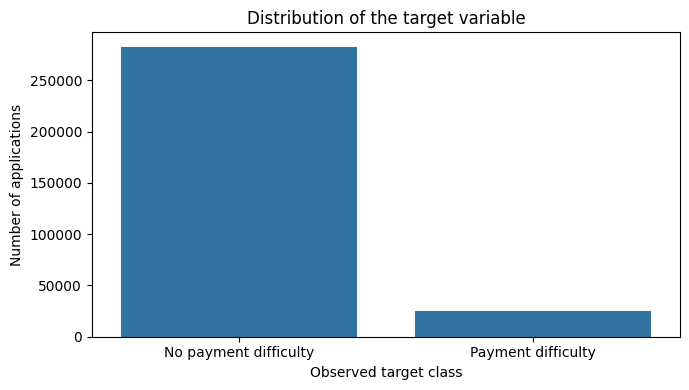

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(
    data=application_train,
    x="TARGET",
    ax=ax,
)

ax.set_title("Distribution of the target variable")
ax.set_xlabel("Observed target class")
ax.set_ylabel("Number of applications")
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No payment difficulty", "Payment difficulty"]
)

plt.tight_layout()
plt.show()

### Interpretation

The target is strongly imbalanced:

- approximately 91.9% of applications have `TARGET = 0`;
- approximately 8.1% have `TARGET = 1`.

Consequently:

- accuracy alone will not be sufficient for model evaluation;
- train-validation splits should preserve the target distribution;
- ROC-AUC and PR-AUC should be reported;
- the classification threshold should not automatically be fixed at 0.5;
- class weighting and resampling methods may be compared during the
  modeling phase.

No class-imbalance treatment is applied in this notebook.

## 7. Missing-value analysis

Missing values are quantified at this stage, but no variable is
removed and no imputation is performed.

In [13]:
missing_summary = (
    application_train.isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .to_frame()
)

missing_summary["dtype"] = application_train.dtypes.astype(str)

missing_summary = (
    missing_summary
    .sort_values("missing_pct", ascending=False)
)

missing_summary.head(20)

,missing_pct,dtype
COMMONAREA_MEDI,69.872297,float64
COMMONAREA_AVG,69.872297,float64
COMMONAREA_MODE,69.872297,float64
NONLIVINGAPARTMENTS_MODE,69.432963,float64
NONLIVINGAPARTMENTS_AVG,69.432963,float64
NONLIVINGAPARTMENTS_MEDI,69.432963,float64
FONDKAPREMONT_MODE,68.386172,object
LIVINGAPARTMENTS_MODE,68.354953,float64
LIVINGAPARTMENTS_AVG,68.354953,float64
LIVINGAPARTMENTS_MEDI,68.354953,float64


In [14]:
for threshold in [0, 20, 40, 60, 80]:
    n_columns = (missing_summary["missing_pct"] > threshold).sum()
    print(
        f"Colonnes avec plus de {threshold}% de valeurs manquantes: "
        f"{n_columns}"
    )

Colonnes avec plus de 0% de valeurs manquantes: 67
Colonnes avec plus de 20% de valeurs manquantes: 50
Colonnes avec plus de 40% de valeurs manquantes: 49
Colonnes avec plus de 60% de valeurs manquantes: 17
Colonnes avec plus de 80% de valeurs manquantes: 0


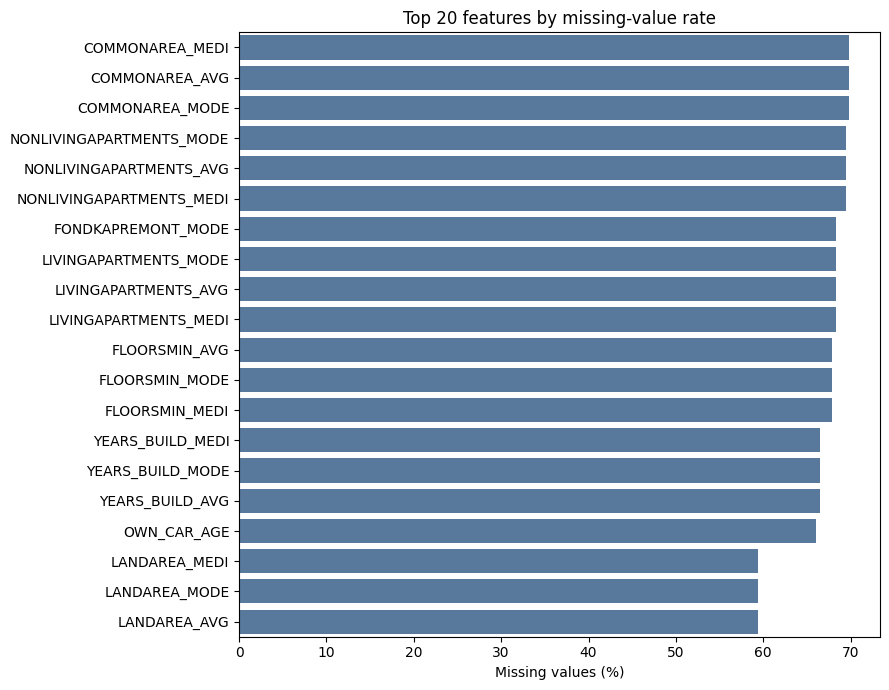

In [15]:
top_missing = missing_summary.head(20).reset_index()
top_missing = top_missing.rename(columns={"index": "feature"})

fig, ax = plt.subplots(figsize=(9, 7))

sns.barplot(
    data=top_missing,
    y="feature",
    x="missing_pct",
    color="#4C78A8",
    ax=ax,
)

ax.set_title("Top 20 features by missing-value rate")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

- 67 variables contain at least one missing value.
- 50 variables contain more than 20% missing values.
- 17 variables contain more than 60% missing values.
- No variable contains more than 80% missing values.

A high missing-value rate is not sufficient by itself to remove a
variable. Missingness may contain information and must be investigated
during the preprocessing and exploratory-analysis phases.

In [16]:
feature_cardinality = pd.DataFrame(
    {
        "feature": application_train.columns,
        "n_unique": [
            application_train[column].nunique(dropna=False)
            for column in application_train.columns
        ],
    }
)

feature_cardinality["unique_ratio"] = (
    feature_cardinality["n_unique"]
    / len(application_train)
)

constant_features = (
    feature_cardinality[
        feature_cardinality["n_unique"] <= 1
    ]
    .sort_values("feature")
)

highest_cardinality_features = (
    feature_cardinality
    .sort_values("unique_ratio", ascending=False)
    .head(20)
)

print(f"Constant features: {len(constant_features)}")

highest_cardinality_features

Constant features: 0


,feature,n_unique,unique_ratio
0,SK_ID_CURR,307511,1.000000
42,EXT_SOURCE_2,119832,0.389684
41,EXT_SOURCE_1,114585,0.372621
17,DAYS_BIRTH,17460,0.056778
19,DAYS_REGISTRATION,15688,0.051016
9,AMT_ANNUITY,13673,0.044463
18,DAYS_EMPLOYED,12574,0.040890
20,DAYS_ID_PUBLISH,6168,0.020058
8,AMT_CREDIT,5603,0.018220
69,LIVINGAREA_MODE,5302,0.017242


### Interpretation

No constant variable was identified.

`SK_ID_CURR` is unique for every observation and acts as a technical
identifier. It must be retained for joins and prediction tracking, but
excluded from the model feature matrix.

Other high-cardinality variables, such as `EXT_SOURCE_1`,
`EXT_SOURCE_2`, `DAYS_BIRTH` and `AMT_ANNUITY`, are continuous or
quasi-continuous measurements.

Therefore, high cardinality alone is not sufficient to classify a
variable as an identifier or to remove it.

In [17]:
def build_feature_audit(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """Create a feature-level data-quality report."""
    records = []

    for column in df.columns:
        series = df[column]
        non_missing = series.dropna()

        non_missing_frequencies = (
            non_missing.value_counts(normalize=True)
        )

        record = {
            "feature": column,
            "dtype": str(series.dtype),
            "n_unique": series.nunique(dropna=True),
            "unique_ratio": (
                series.nunique(dropna=True) / len(series)
            ),
            "missing_count": series.isna().sum(),
            "missing_pct": series.isna().mean() * 100,
            "most_frequent_non_missing_value": (
                non_missing_frequencies.index[0]
                if not non_missing_frequencies.empty
                else np.nan
            ),
            "most_frequent_non_missing_pct": (
                non_missing_frequencies.iloc[0] * 100
                if not non_missing_frequencies.empty
                else np.nan
            ),
        }

        if pd.api.types.is_numeric_dtype(series):
            record.update(
                {
                    "minimum": series.min(),
                    "median": series.median(),
                    "maximum": series.max(),
                    "zero_pct": series.eq(0).mean() * 100,
                    "negative_pct": series.lt(0).mean() * 100,
                    "infinite_count": np.isinf(series).sum(),
                }
            )

        records.append(record)

    return (
        pd.DataFrame(records)
        .sort_values("missing_pct", ascending=False)
        .reset_index(drop=True)
    )


feature_audit = build_feature_audit(application_train)
feature_audit.head(20)

,feature,dtype,n_unique,unique_ratio,missing_count,missing_pct,most_frequent_non_missing_value,most_frequent_non_missing_pct,minimum,median,maximum,zero_pct,negative_pct,infinite_count
0,COMMONAREA_MEDI,float64,3202,0.010413,214865,69.872297,0.0,9.380869,0.0,0.0208,1.0,2.826240,0.0,0.0
1,COMMONAREA_AVG,float64,3181,0.010344,214865,69.872297,0.0,9.112104,0.0,0.0211,1.0,2.745268,0.0,0.0
2,COMMONAREA_MODE,float64,3128,0.010172,214865,69.872297,0.0,10.459167,0.0,0.0190,1.0,3.151107,0.0,0.0
3,NONLIVINGAPARTMENTS_MODE,float64,167,0.000543,213514,69.432963,0.0,63.039246,0.0,0.0000,1.0,19.269229,0.0,0.0
4,NONLIVINGAPARTMENTS_AVG,float64,386,0.001255,213514,69.432963,0.0,58.032703,0.0,0.0000,1.0,17.738878,0.0,0.0
5,NONLIVINGAPARTMENTS_MEDI,float64,214,0.000696,213514,69.432963,0.0,59.679564,0.0,0.0000,1.0,18.242274,0.0,0.0
6,FONDKAPREMONT_MODE,object,4,0.000013,210295,68.386172,reg oper account,75.944289,NaN,NaN,NaN,NaN,NaN,NaN
7,LIVINGAPARTMENTS_MODE,float64,736,0.002393,210199,68.354953,0.0551,5.067207,0.0,0.0771,1.0,0.168774,0.0,0.0
8,LIVINGAPARTMENTS_AVG,float64,1868,0.006075,210199,68.354953,0.0504,4.390003,0.0,0.0756,1.0,0.135930,0.0,0.0
9,LIVINGAPARTMENTS_MEDI,float64,1097,0.003567,210199,68.354953,0.0513,4.624301,0.0,0.0761,1.0,0.140808,0.0,0.0


## 8. Potential anomalies and special values

Values that appear unusual are flagged for investigation. They are not
automatically treated as errors.

Their meaning must first be checked against the dataset documentation
and the business definition of each variable.

In [18]:
infinite_summary = (
    feature_audit[
        feature_audit["infinite_count"].fillna(0) > 0
    ][
        ["feature", "infinite_count"]
    ]
)

infinite_summary

,feature,infinite_count


In [19]:
special_value_checks = pd.DataFrame(
    [
        {
            "feature": "DAYS_EMPLOYED",
            "value": 365243,
            "count": application_train[
                "DAYS_EMPLOYED"
            ].eq(365243).sum(),
        },
        {
            "feature": "CODE_GENDER",
            "value": "XNA",
            "count": application_train[
                "CODE_GENDER"
            ].eq("XNA").sum(),
        },
        {
            "feature": "ORGANIZATION_TYPE",
            "value": "XNA",
            "count": application_train[
                "ORGANIZATION_TYPE"
            ].eq("XNA").sum(),
        },
        {
            "feature": "NAME_FAMILY_STATUS",
            "value": "Unknown",
            "count": application_train[
                "NAME_FAMILY_STATUS"
            ].eq("Unknown").sum(),
        },
    ]
)

special_value_checks["percentage"] = (
    special_value_checks["count"]
    / len(application_train)
    * 100
)

special_value_checks

,feature,value,count,percentage
0,DAYS_EMPLOYED,365243,55374,18.007161
1,CODE_GENDER,XNA,4,0.001301
2,ORGANIZATION_TYPE,XNA,55374,18.007161
3,NAME_FAMILY_STATUS,Unknown,2,0.000650


In [20]:
numeric_extremes = (
    application_train[numeric_columns]
    .describe(percentiles=[0.01, 0.50, 0.99])
    .T[
        ["min", "1%", "50%", "99%", "max"]
    ]
)

numeric_extremes["max_to_p99_ratio"] = (
    numeric_extremes["max"]
    / numeric_extremes["99%"].replace(0, np.nan)
)

numeric_extremes.sort_values(
    "max_to_p99_ratio",
    ascending=False,
).head(20)

,min,1%,50%,99%,max,max_to_p99_ratio
AMT_INCOME_TOTAL,25650.0,45000.00,147150.0000,472500.000000,117000000.0,247.619048
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.00,0.0000,2.000000,261.0,130.500000
OBS_30_CNT_SOCIAL_CIRCLE,0.0,0.00,0.0000,10.000000,348.0,34.800000
OBS_60_CNT_SOCIAL_CIRCLE,0.0,0.00,0.0000,10.000000,344.0,34.400000
DEF_30_CNT_SOCIAL_CIRCLE,0.0,0.00,0.0000,2.000000,34.0,17.000000
DEF_60_CNT_SOCIAL_CIRCLE,0.0,0.00,0.0000,2.000000,24.0,12.000000
NONLIVINGAPARTMENTS_MODE,0.0,0.00,0.0000,0.097300,1.0,10.277492
NONLIVINGAPARTMENTS_MEDI,0.0,0.00,0.0000,0.104800,1.0,9.541985
NONLIVINGAPARTMENTS_AVG,0.0,0.00,0.0000,0.108100,1.0,9.250694
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.00,0.0000,1.000000,8.0,8.000000


### Interpretation

Several potential special values or categories have been identified,
including `DAYS_EMPLOYED = 365243` and categorical values such as
`XNA` or `Unknown`.

These observations are only flagged at this stage. No replacement,
imputation, clipping or row deletion is performed before their meaning
has been verified.

In [21]:
REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

feature_audit.to_csv(
    REPORT_DIR / "application_train_feature_audit.csv",
    index=False,
)

target_summary.to_csv(
    REPORT_DIR / "target_summary.csv",
    index_label="target_class",
)

missing_summary.to_csv(
    REPORT_DIR / "application_train_missing_summary.csv",
    index_label="feature",
)

key_check_summary.to_csv(
    REPORT_DIR / "table_key_check.csv",
    index=False,
)

special_value_checks.to_csv(
    REPORT_DIR / "special_value_checks.csv",
    index=False,
)

print(f"Audit tables exported to: {REPORT_DIR.resolve()}")

Audit tables exported to: C:\Users\manhh\Documents\home-credit-risk-scoring\reports


## 9. Main findings

- `application_train` contains 307,511 observations and 122 columns.
- One row corresponds to one current loan application.
- `SK_ID_CURR` is unique and acts as a joining and
  prediction-tracking identifier.
- `SK_ID_CURR` will be excluded from the future feature matrix.
- No duplicated rows or duplicated current-application identifiers
  were detected.
- The target contains no missing values and is strongly imbalanced:
  approximately 8.1% of applications are associated with payment
  difficulties.
- Sixty-seven variables contain missing values.
- Seventeen variables contain more than 60% missing observations.
- No constant feature was detected.
- High cardinality may indicate an identifier or a legitimate
  continuous measurement and is not by itself a feature-removal rule.
- Several potential special values and categories require further
  investigation.
- Historical tables contain repeated observations for each applicant
  and must be aggregated before being joined to the application-level
  modeling table.

## Decisions deferred to later phases

No variable is removed, imputed, transformed, clipped or encoded in
this notebook.

Missing-value treatment, anomaly handling, feature engineering,
class-imbalance strategies and feature selection will be addressed in
later phases.